### The rating response
Edit the numbers marked `👈` and re-run.

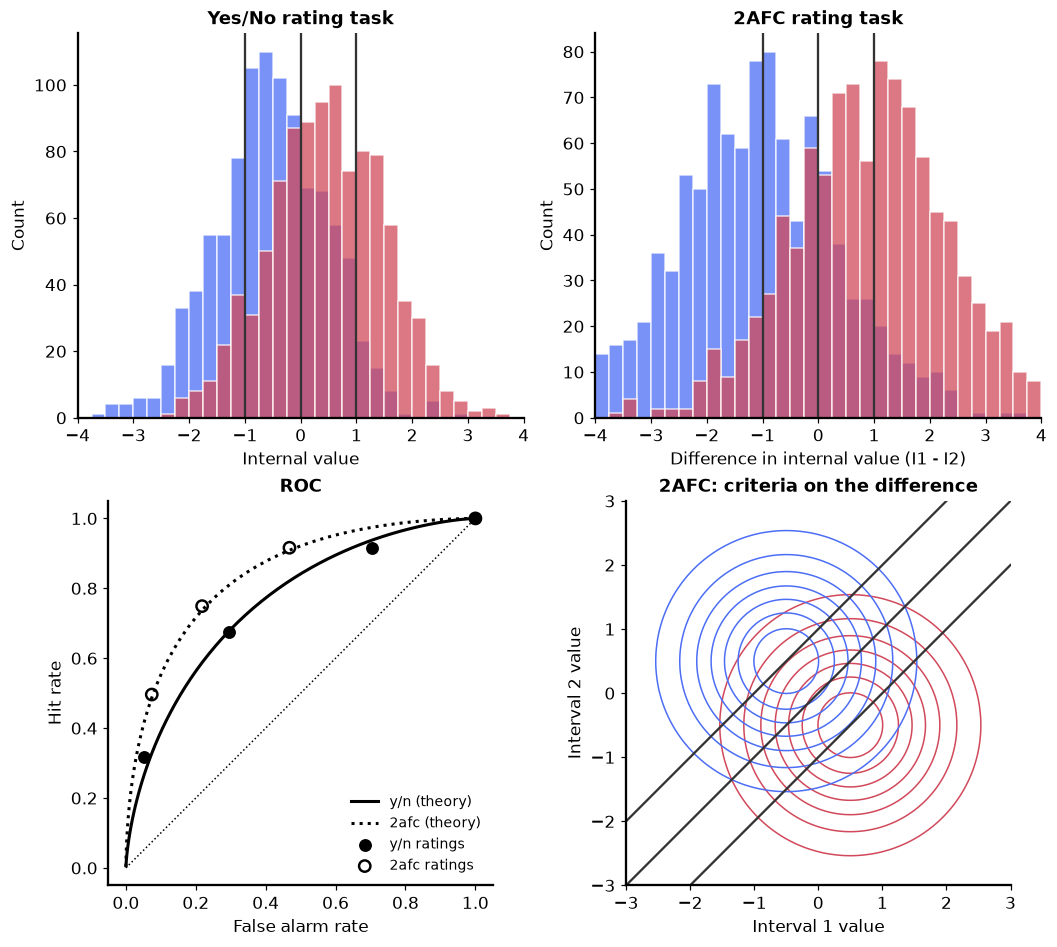

In [1]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})
NOISE  = "#4c6ef5"
SIGNAL = "#d1495b"
CRIT   = "#333333"

ntrials         = 2000
signal_strength = 1       # 👈 how far the signal shifts the distribution
n_ratings       = 4       # 👈 number of points on the rating scale (e.g. 4 -> "1..4")
noise_mean, noise_sd = -0.5, 1

rng  = np.random.default_rng()
half = ntrials // 2
signal_mean = noise_mean + signal_strength

# the observer places (n_ratings - 1) criteria along the internal value
these_criteria = np.linspace(-1, 1, n_ratings - 1)

def fa_hit(noise_vals, signal_vals, criteria):
    """Hit/false-alarm rate at each rating threshold (the points of the ROC)."""
    levels = len(criteria) + 1
    rn = np.digitize(noise_vals,  criteria) + 1   # ratings 1..levels
    rs = np.digitize(signal_vals, criteria) + 1
    cis = np.arange(1, levels + 1)
    fa  = np.array([np.mean(rn >= ci) for ci in cis])
    hit = np.array([np.mean(rs >= ci) for ci in cis])
    return fa, hit

# ---- 1. Yes/No rating task -------------------------------------------------
noise = rng.standard_normal(ntrials) * noise_sd + noise_mean
noise_samps, signal_samps = noise[:half], noise[half:] + signal_strength
fa_yn, hit_yn = fa_hit(noise_samps, signal_samps, these_criteria)

# ---- 2. 2AFC rating task (criteria placed on the difference I1 - I2) -------
i1 = rng.standard_normal(ntrials) * noise_sd + noise_mean
i2 = rng.standard_normal(ntrials) * noise_sd + noise_mean
i1[:half] += signal_strength      # signal in interval 1
i2[half:] += signal_strength      # signal in interval 2
diff_sig1 = i1[:half] - i2[:half]   # signal in 1 -> difference tends positive
diff_sig2 = i1[half:] - i2[half:]   # signal in 2 -> difference tends negative
fa_2afc, hit_2afc = fa_hit(diff_sig2, diff_sig1, these_criteria)

fig, axs = plt.subplots(2, 2, figsize=(9.5, 8.5), constrained_layout=True)
bins = np.arange(-4, 4 + 0.25, 0.25)

# top-left: yes/no distributions with the rating criteria
ax = axs[0, 0]
ax.hist(noise_samps,  bins=bins, color=NOISE,  alpha=0.75, edgecolor="white")
ax.hist(signal_samps, bins=bins, color=SIGNAL, alpha=0.75, edgecolor="white")
for c in these_criteria:
    ax.axvline(c, color=CRIT, lw=1.5)
ax.set(xlim=(-4, 4), xlabel="Internal value", ylabel="Count", title="Yes/No rating task")

# top-right: 2AFC difference distribution with the rating criteria
ax = axs[0, 1]
ax.hist(diff_sig2, bins=bins, color=NOISE,  alpha=0.75, edgecolor="white")
ax.hist(diff_sig1, bins=bins, color=SIGNAL, alpha=0.75, edgecolor="white")
for c in these_criteria:
    ax.axvline(c, color=CRIT, lw=1.5)
ax.set(xlim=(-4, 4), xlabel="Difference in internal value (I1 - I2)", ylabel="Count",
       title="2AFC rating task")

# bottom-left: the ROC, with a point per criterion, plus the theoretical curves
ax = axs[1, 0]
xs = np.linspace(-3, 3, 100)
ax.plot(1 - norm.cdf(xs, noise_mean, noise_sd),
        1 - norm.cdf(xs, signal_mean, noise_sd), color="k", lw=2, label="y/n (theory)")
ax.plot(1 - norm.cdf(xs, noise_mean, noise_sd/np.sqrt(2)),
        1 - norm.cdf(xs, signal_mean, noise_sd/np.sqrt(2)), color="k", lw=2, ls=":",
        label="2afc (theory)")
ax.scatter(fa_yn,   hit_yn,   55, color="k", label="y/n ratings", zorder=3)
ax.scatter(fa_2afc, hit_2afc, 55, facecolors="none", edgecolors="k", linewidths=1.6,
           label="2afc ratings", zorder=3)
ax.plot([0, 1], [0, 1], "k:", lw=1)
ax.set(xlabel="False alarm rate", ylabel="Hit rate", title="ROC")
ax.set_aspect("equal"); ax.legend(loc="lower right", fontsize=9)

# bottom-right: the 2D-gaussian view; the criteria are diagonal bands on the difference
ax = axs[1, 1]
gx, gy = np.meshgrid(np.linspace(-4, 4, 120), np.linspace(-4, 4, 120))
pos = np.dstack([gx, gy])
cov = [[noise_sd**2, 0], [0, noise_sd**2]]
ax.contour(gx, gy, multivariate_normal([signal_mean, noise_mean], cov).pdf(pos),
           colors=SIGNAL, linewidths=1)
ax.contour(gx, gy, multivariate_normal([noise_mean, signal_mean], cov).pdf(pos),
           colors=NOISE, linewidths=1)
for c in these_criteria:
    ax.plot([-3, 3], [-3 - c, 3 - c], color=CRIT, lw=1.5)   # line where I1 - I2 = c
ax.set(xlim=(-3, 3), ylim=(-3, 3), xlabel="Interval 1 value", ylabel="Interval 2 value",
       title="2AFC: criteria on the difference")
ax.set_aspect("equal")
plt.show()
